1. Tests on how to change hyperparameters during a run through costum random forest model

In [ ]:
import os

if os.environ.get("PYTHONHASHSEED") != "0":
    raise RuntimeError(
        "Restart this notebook kernel with PYTHONHASHSEED=0 before running this experiment."
    )

print("PYTHONHASHSEED=0")

In [33]:
from smac.model.random_forest.random_forest import RandomForest
import numpy as np
from smac import Scenario
from smac.model.random_forest.random_forest import EPMRandomForest

class AdaptiveForest(RandomForest):
    def _train(self, X: np.ndarray, y: np.ndarray) -> "AdaptiveForest":
        n = X.shape[0]  # number of surrogate training observations

        if n > 22:
            self._rf_opts["max_depth"] = 1

        print(f"Training RF with n={n}, max_depth={self._rf_opts['max_depth']}")

        return super()._train(X, y)
    
def get_model(  # type: ignore
        scenario: Scenario,
        *,
        n_trees: int = 10,
        ratio_features: float = 1.0,
        min_samples_split: int = 2,
        min_samples_leaf: int = 1,
        max_depth: int = 2**20,
        bootstrapping: bool = True,
    ) -> RandomForest:
        """Returns a random forest as surrogate model.

        Parameters
        ----------
        n_trees : int, defaults to 10
            The number of trees in the random forest.
        ratio_features : float, defaults to 5.0 / 6.0
            The ratio of features that are considered for splitting.
        min_samples_split : int, defaults to 3
            The minimum number of data points to perform a split.
        min_samples_leaf : int, defaults to 3
            The minimum number of data points in a leaf.
        max_depth : int, defaults to 20
            The maximum depth of a single tree.
        bootstrapping : bool, defaults to True
            Enables bootstrapping.
        """
        return AdaptiveForest(
            log_y=True,
            n_trees=n_trees,
            bootstrapping=bootstrapping,
            ratio_features=ratio_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_depth=max_depth,
            configspace=scenario.configspace,
            instance_features=scenario.instance_features,
            seed=scenario.seed,
        )

class AdaptiveForest2(RandomForest):
    def _train(self, X: np.ndarray, y: np.ndarray) -> "AdaptiveForest":
        n = X.shape[0]  # number of surrogate training observations

        if 35 >= n > 22:
            self._rf_opts["max_depth"] = 1
        elif n >35:
             self._rf_opts["max_depth"] = 2**20

        print(f"Training RF with n={n}, max_depth={self._rf_opts['max_depth']}")

        return super()._train(X, y)
    
def get_model2(  # type: ignore
        scenario: Scenario,
        *,
        n_trees: int = 10,
        ratio_features: float = 1.0,
        min_samples_split: int = 2,
        min_samples_leaf: int = 1,
        max_depth: int = 2**20,
        bootstrapping: bool = True,
    ) -> RandomForest:
        """Returns a random forest as surrogate model.

        Parameters
        ----------
        n_trees : int, defaults to 10
            The number of trees in the random forest.
        ratio_features : float, defaults to 5.0 / 6.0
            The ratio of features that are considered for splitting.
        min_samples_split : int, defaults to 3
            The minimum number of data points to perform a split.
        min_samples_leaf : int, defaults to 3
            The minimum number of data points in a leaf.
        max_depth : int, defaults to 20
            The maximum depth of a single tree.
        bootstrapping : bool, defaults to True
            Enables bootstrapping.
        """
        return AdaptiveForest2(
            log_y=True,
            n_trees=n_trees,
            bootstrapping=bootstrapping,
            ratio_features=ratio_features,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_depth=max_depth,
            configspace=scenario.configspace,
            instance_features=scenario.instance_features,
            seed=scenario.seed,
        )

In [34]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ConfigSpace import ConfigurationSpace, Configuration, Float
from smac import Scenario
from smac import HyperparameterOptimizationFacade as HPOFacade


SEED = 67
N_TRIALS = 75
MODELS = [0,1,2]

def branin(x1, x2):
    a = 1.0
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6.0
    s = 10.0
    t = 1 / (8 * np.pi)

    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s


def branin_eval(config: Configuration, seed: int = 0) -> float:
    x1 = config["x1"]
    x2 = config["x2"]
    return branin(x1, x2)


def make_configspace(seed: int = SEED) -> ConfigurationSpace:
    cs = ConfigurationSpace(seed=seed)
    cs.add(
        Float("x1", (-5, 10)),
        Float("x2", (0, 15)),
    )
    return cs


def run_one_split(model_nr: int = 0):
    cs = make_configspace(SEED)

    scenario = Scenario(
        configspace=cs,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=SEED,
    )

    if model_nr == 0:
        model = HPOFacade.get_model(
            scenario=scenario,
        )
    elif model_nr ==1:
        model = get_model(
            scenario = scenario
        )
    elif model_nr == 2:
        model = get_model2(
            scenario = scenario
        )

    smac = HPOFacade(
        scenario=scenario,
        target_function=branin_eval,
        model=model,
        overwrite=True,
    )

    incumbent = smac.optimize()
    incumbent_cost = smac.runhistory.get_cost(incumbent)

    trials = sorted(
        smac.runhistory.items(),
        key=lambda item: item[1].starttime,
    )

    costs = np.array([trial_value.cost for _, trial_value in trials], dtype=float)
    best_so_far = np.minimum.accumulate(costs)
    trial_numbers = np.arange(1, len(costs) + 1)

    convergence = pd.DataFrame({
        "depth": model,
        "trial": trial_numbers,
        "cost": costs,
        "best_so_far": best_so_far,
    })

    return {
        "depth": model,
        "smac": smac,
        "incumbent": incumbent,
        "incumbent_cost": incumbent_cost,
        "convergence": convergence,
    }


results = []

for model_nr in MODELS:
    print(f"Running RF max_depth={model_nr}")
    result = run_one_split(model_nr)
    results.append(result)

    print("  incumbent:", dict(result["incumbent"]))
    print("  incumbent cost:", result["incumbent_cost"])
    print()


summary_df = pd.DataFrame({
    "depth": [r["depth"] for r in results],
    "incumbent_cost": [r["incumbent_cost"] for r in results],
})

print(summary_df)

Running RF max_depth=0
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 20 to 18 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 18 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config f23915 as new incumbent because there are no incumbents yet.


[INFO][abstract_intensifier.py:630] Added config bb7619 and rejected config f23915 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config a2b59e and rejected config bb7619 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 1d2b15 and rejected config a2b59e as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 738cf4 and rejected config 1d2b15 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config fd03d9 and rejected config 738cf4 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][smbo.py:334] Finished 50 trials.
[INFO][abstract_intensifier.py:630] Added config c5dd6f and rejected config fd03d9 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstr

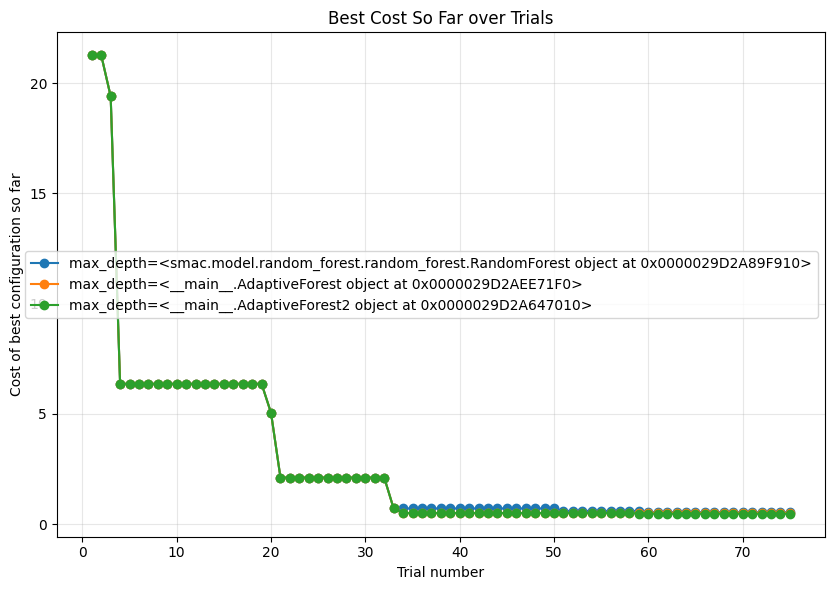

In [35]:
fig, ax = plt.subplots(figsize=(9, 6))

for result in results:
    df = result["convergence"]
    max_split = result["depth"]

    ax.plot(
        df["trial"],
        df["best_so_far"],
        marker="o",
        label=f"max_depth={max_split}",
    )

ax.set_title("Best Cost So Far over Trials")
ax.set_xlabel("Trial number")
ax.set_ylabel("Cost of best configuration so far")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

2. Change Hyperparameters during the run through callbacks

In [36]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ConfigSpace import ConfigurationSpace, Configuration, Float
from smac import Scenario
from smac import HyperparameterOptimizationFacade as HPOFacade
from smac.callback import Callback

class AdaptiveDepthCallback1(Callback):
    def on_next_configurations_start(self, config_selector) -> None:
        model = config_selector._model
        rh = config_selector._runhistory

        # In your deterministic Branin setup:
        # n_trials == number of surrogate training observations
        n = len(rh)

        if n > 22:
            model._rf_opts["max_depth"] = 1

        print(f"[Callback 1] n={n}, max_depth={model._rf_opts['max_depth']}")

class AdaptiveDepthCallback2(Callback):
    def on_next_configurations_start(self, config_selector) -> None:
        model = config_selector._model
        rh = config_selector._runhistory

        n = len(rh)

        if 35 >= n > 22:
            model._rf_opts["max_depth"] = 1
        elif n > 35:
            model._rf_opts["max_depth"] = 2**20

        print(f"[Callback 2] n={n}, max_depth={model._rf_opts['max_depth']}")

In [37]:
SEED = 67
N_TRIALS = 75

# 0 = normal HPO RF
# 1 = callback policy like AdaptiveForest
# 2 = callback policy like AdaptiveForest2
MODELS = [0, 1, 2]


def branin(x1, x2):
    a = 1.0
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6.0
    s = 10.0
    t = 1 / (8 * np.pi)

    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s


def branin_eval(config: Configuration, seed: int = 0) -> float:
    x1 = config["x1"]
    x2 = config["x2"]
    return branin(x1, x2)


def make_configspace(seed: int = SEED) -> ConfigurationSpace:
    cs = ConfigurationSpace(seed=seed)
    cs.add(
        Float("x1", (-5, 10)),
        Float("x2", (0, 15)),
    )
    return cs


def make_callback(model_nr: int):
    if model_nr == 0:
        return None
    elif model_nr == 1:
        return AdaptiveDepthCallback1()
    elif model_nr == 2:
        return AdaptiveDepthCallback2()
    else:
        raise ValueError(f"Unknown model_nr: {model_nr}")


def model_label(model_nr: int) -> str:
    if model_nr == 0:
        return "normal"
    elif model_nr == 1:
        return "depth_1_after_22"
    elif model_nr == 2:
        return "depth_1_23_to_35_then_reset"
    else:
        raise ValueError(f"Unknown model_nr: {model_nr}")


def run_one_split(model_nr: int = 0):
    cs = make_configspace(SEED)

    scenario = Scenario(
        configspace=cs,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=SEED,
        name=f"branin_callback_model_{model_nr}",
        output_directory=Path("smac_output_callback_depth"),
    )

    # Always use the normal HPOFacade RF model.
    # The callback modifies it during the run.
    model = HPOFacade.get_model(scenario=scenario)

    callback = make_callback(model_nr)
    callbacks = [] if callback is None else [callback]

    smac = HPOFacade(
        scenario=scenario,
        target_function=branin_eval,
        model=model,
        callbacks=callbacks,
        overwrite=True,
    )

    incumbent = smac.optimize()
    incumbent_cost = smac.runhistory.get_cost(incumbent)

    trials = sorted(
        smac.runhistory.items(),
        key=lambda item: item[1].starttime,
    )

    costs = np.array([trial_value.cost for _, trial_value in trials], dtype=float)
    best_so_far = np.minimum.accumulate(costs)
    trial_numbers = np.arange(1, len(costs) + 1)

    label = model_label(model_nr)

    convergence = pd.DataFrame({
        "model_nr": model_nr,
        "policy": label,
        "trial": trial_numbers,
        "cost": costs,
        "best_so_far": best_so_far,
    })

    return {
        "model_nr": model_nr,
        "policy": label,
        "smac": smac,
        "model": model,
        "incumbent": incumbent,
        "incumbent_cost": incumbent_cost,
        "convergence": convergence,
    }


results = []

for model_nr in MODELS:
    print(f"Running model_nr={model_nr}, policy={model_label(model_nr)}")
    result = run_one_split(model_nr)
    results.append(result)

    print("  incumbent:", dict(result["incumbent"]))
    print("  incumbent cost:", result["incumbent_cost"])
    print()


summary_df = pd.DataFrame({
    "model_nr": [r["model_nr"] for r in results],
    "policy": [r["policy"] for r in results],
    "incumbent_cost": [r["incumbent_cost"] for r in results],
})

print(summary_df)

Running model_nr=0, policy=normal
[INFO][abstract_initial_design.py:91] Reducing the number of initial configurations from 20 to 18 (max_ratio == 0.25).
[INFO][abstract_initial_design.py:143] Using 18 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config f23915 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config bb7619 and rejected config f23915 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config a2b59e and rejected config bb7619 as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 1d2b15 and rejected config a2b59e as incumbent because it is not better than the incumbents on 1 instances: 
[INFO][abstract_intensifier.py:630] Added config 738cf4 and rejected

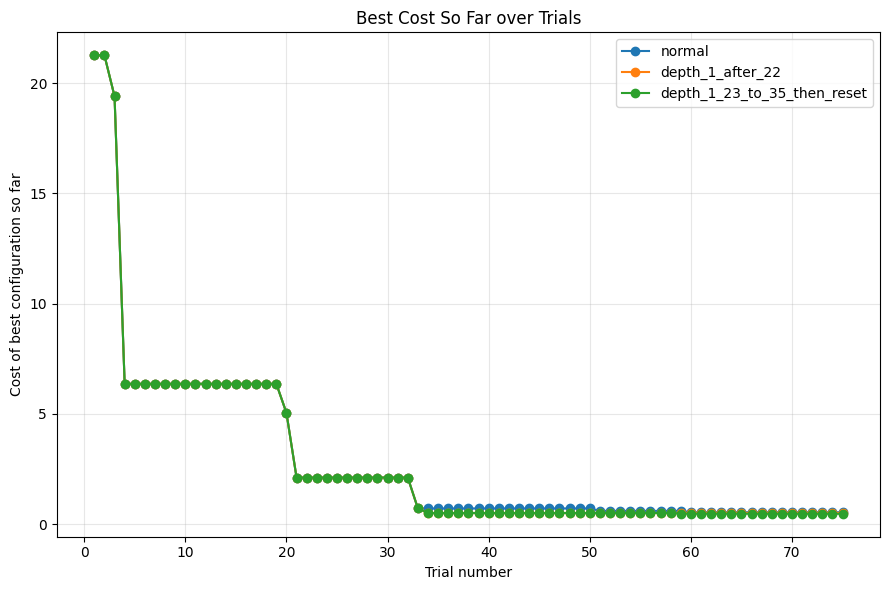

In [38]:
fig, ax = plt.subplots(figsize=(9, 6))

for result in results:
    df = result["convergence"]

    ax.plot(
        df["trial"],
        df["best_so_far"],
        marker="o",
        label=result["policy"],
    )

ax.set_title("Best Cost So Far over Trials")
ax.set_xlabel("Trial number")
ax.set_ylabel("Cost of best configuration so far")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()